## Pregunta 1

Analice cuantos valores faltantes hay en los datos 

Se calculan datos faltantes de cada variable (columna) y su porcentaje.

In [123]:
import pandas as pd

df = pd.read_csv("recipeData.csv", encoding="latin1")

faltantes = df.isnull().sum()
porcentaje = (faltantes / len(df)) * 100
faltantes_df = pd.DataFrame({
    "Faltantes": faltantes,
    "Porcentaje": porcentaje
}).sort_values(by="Porcentaje", ascending=False)

print(faltantes_df)

               Faltantes  Porcentaje
PrimingAmount      69098   93.551401
PrimingMethod      67116   90.867982
PitchRate          39348   53.273040
MashThickness      29934   40.527477
PrimaryTemp        22785   30.848486
BoilGravity         3144    4.256644
Style                767    1.038437
Name                 175    0.236932
BoilSize             173    0.234224
BrewMethod           173    0.234224
SugarScale           173    0.234224
Efficiency           173    0.234224
UserId;;             173    0.234224
BoilTime             173    0.234224
Color                173    0.234224
IBU                  173    0.234224
ABV                  173    0.234224
FG                   173    0.234224
OG                   173    0.234224
Size(L)              173    0.234224
StyleID              173    0.234224
URL                  173    0.234224
BeerID                 0    0.000000


## Pregunta 2

 Indentficar si existen variables con muchos datos faltantes.

Variables con muchos datos faltantes: mayor a la media de datos faltantes.

Variables con datos faltantes mayores a la media de datos faltantes: 
### PrimingAmount 93.55%
### PrimingMethod 90.86%
### PitchRate 53.27%
### MashThickness 40.52%
### PrimaryTemp 30.84%
Para este caso el tratamiento será el siguiente:

1- Eliminamos las variables con datos faltantes mayores al promedio de datos faltantes. Que 
en este caso de es de 13.82%

2-  Una vez que tengamos las variables eliminadas, en nuestro nuevo dataFrame, llamado "df_limpio" haremos un imputacion con el resto de datos faltantes, por la mediana o moda según corresponda al tipo de variable. 


In [124]:
media_nulos = porcentaje.mean()
print(f"\nMedia de porcentaje de nulos: {media_nulos:.2f}%")

variables_con_muchos_nulos = faltantes_df[faltantes_df["Porcentaje"] > media_nulos]
print("\nVariables con muchos nulos (se eliminarán):\n")
print(variables_con_muchos_nulos)

df_limpio = df.drop(columns=variables_con_muchos_nulos.index)

# Imputa nulos restantes por mediana o moda según corresponda.
for col in df_limpio.columns:
    if df_limpio[col].isnull().sum() > 0:
        if pd.api.types.is_numeric_dtype(df_limpio[col]):
            df_limpio[col] = df_limpio[col].fillna(df_limpio[col].median())
        else:
            df_limpio[col] = df_limpio[col].fillna(df_limpio[col].mode()[0])

#####

faltantes_limpio = df_limpio.isnull().sum()
porcentaje_limpio = (faltantes_limpio / len(df_limpio)) * 100
faltantes_df_limpio = pd.DataFrame({
    "Faltantes": faltantes_limpio,
    "Porcentaje": porcentaje_limpio
}).sort_values(by="Porcentaje", ascending=False)

print("\nDatos después de eliminar variables con muchos nulos e imputar el resto:\n")
print(faltantes_df_limpio)

### DF limpio
 
print("\nDataFrame limpio (primeras 10 filas):\n")
print(df_limpio.head(10))


Media de porcentaje de nulos: 13.82%

Variables con muchos nulos (se eliminarán):

               Faltantes  Porcentaje
PrimingAmount      69098   93.551401
PrimingMethod      67116   90.867982
PitchRate          39348   53.273040
MashThickness      29934   40.527477
PrimaryTemp        22785   30.848486

Datos después de eliminar variables con muchos nulos e imputar el resto:

             Faltantes  Porcentaje
BeerID               0         0.0
Name                 0         0.0
BrewMethod           0         0.0
SugarScale           0         0.0
Efficiency           0         0.0
BoilGravity          0         0.0
BoilTime             0         0.0
BoilSize             0         0.0
Color                0         0.0
IBU                  0         0.0
ABV                  0         0.0
FG                   0         0.0
OG                   0         0.0
Size(L)              0         0.0
StyleID              0         0.0
Style                0         0.0
URL                  0  

## Pregunta 3

• Detecte si los datos faltantes se dan en varias variables a la vez y proponga una solución.

* Trabajamos de manera aislada esta pregunta, no se considera el df creado en la pregunta 2, sino que se trabaja con el df original.

3.1 Primero se eliminan las filas del dataframe que tenga mas de 3 variables con valores nulos.

3.2 Posteriormente se eliminan las variables que tengan valores nulos mayor a la media de valores nulos en terminos porcentuales.

3.3 Se imputan valores sobrantes por la mediana o moda según corresponda. 

In [125]:
# 3.1 
df_nulos = df[df.isnull().sum(axis=1) > 2]  
print("Filas con múltiples nulos:\n", df_nulos)
df_limpio = df.dropna(thresh=df.shape[1] - 2)  # se eliminan las filas que tengan 3 o mas valores nulos

# 3.2
faltantes_limpio = df_limpio.isnull().sum()
porcentaje_limpio = (faltantes_limpio / len(df_limpio)) * 100

faltantes_df_2 = pd.DataFrame({
    "Faltantes": faltantes_limpio,
    "Porcentaje": porcentaje_limpio
}).sort_values(by="Porcentaje", ascending=False)
##
media_nulos_2 = porcentaje_limpio.mean()
print(f"Media de porcentaje de nulos: {media_nulos_2:.2f}%")

variables_con_muchos_nulos_2 = faltantes_df_2[faltantes_df_2["Porcentaje"] > media_nulos_2]
print("Variables con muchos nulos:\n", variables_con_muchos_nulos_2)

df_2 = df_limpio.drop(columns=variables_con_muchos_nulos_2.index) # elimicacion columnas con mucho valores faltantes

# 3.3

for col in df_2.columns:
    if df_2[col].isnull().sum() > 0:
        if pd.api.types.is_numeric_dtype(df_2[col]): # para detectar si es numerica 
            df_2[col] = df_2[col].fillna(df_2[col].median())
        else:
            df_2[col] = df_2[col].fillna(df_2[col].mode()[0]) # sino es numero, se le aplica moda, asumiendo que es categorica.



# Ahora imprime df_2 y se verán todas
print(df_2.head(20))  

Filas con múltiples nulos:
       BeerID                                      Name  \
1          2               Southern Tier Pumking clone   
2          3               Zombie Dust Clone - EXTRACT   
3          4             Zombie Dust Clone - ALL GRAIN   
5          6              Sierra Nevada Pale Ale Clone   
6          7  Russian River Pliny the Elder (original)   
...      ...                                       ...   
73853  73854                      Chris ford wheat ipa   
73854  73855                      X Files American Ale   
73855  73856                               Unicorn Pee   
73857  73858                                   Rye IPA   
73860  73861                     Elvis Juice IPA Clone   

                                                     URL  \
1      /homebrew/recipe/view/16367/southern-tier-pumk...   
2      /homebrew/recipe/view/5920/zombie-dust-clone-e...   
3      /homebrew/recipe/view/5916/zombie-dust-clone-a...   
5      /homebrew/recipe/view/28546/

## Pregunta 4 

- Creamos un df que contenga unicamente las variables Style y BoilGravity. Imputamos los datos faltantes de Style por la moda, que en este caso es American IPA.

- Se comparan los datos faltantes de BoilGravity según el estilo de cerveza (Style) y se describe observación.


Los datos faltantes de la variable "BoilGravity" totales son 3.144. Si analizamos por estilo de cerveza, tenemos que los tipos de cervezas con mas datos faltantes en terminos porcentuales de la variable "BoilGravity" son:

- French Cider                  50.00 %

- Metheglin                     28.57 %

- Pyment (Grape Melomel)        20.00 % 

- Scottish Heavy 70/-           17.94 % 

- American Wheat or Rye Beer    17.92 %

Si analizamos por estilo de cerveza, tenemos que los tipos de cervezas con mas datos faltantes en terminos absolutos de la variable "BoilGravity" son:

- American IPA                   - 802  

- American Pale Ale              - 253  

- Imperial IPA                   - 133   

- American Wheat or Rye Beer     - 102    

- American Amber Ale             - 101   

Observacacion:

- Los estilos de cervezas que en terminos absolutos tienen mayores datos faltantes de BoilGravity es porque su cardinalidad es mayor. Como por ejemplo: American IPA  que es la moda de la variable Style y en este caso tienen la mayor cantidad de datos faltantes de la variable BoilGravity (389), por esta razón cuando imputamos lo datos faltantes de style por la moda, el numero de datos faltantes de BoilGravity para el estilo de cerveza Amarican IPA aumenta a 802.

- En cambio las cervezas que tienen mayores datos faltantes de Boilgravity en terminos porcentuales es porque su cardinalidad es menor. 


Moda de Style: American IPA
Nulos en Style después de imputar: 0


C:\Users\Cecilia\AppData\Local\Temp\ipykernel_12716\3154251674.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_Style_BoilGravity['Style'].fillna(moda_style, inplace=True)



Nulos absolutos por estilo:
                            Style  Nulos  Total
6                    American IPA    802  12665
9               American Pale Ale    253   7569
85                   Imperial IPA    133   1476
14     American Wheat or Rye Beer    102    569
3              American Amber Ale    101   2033
..                            ...    ...    ...
72                   French Cider      1      2
69   Flanders Brown Ale/Oud Bruin      1     51
75                   Fruit Lambic      1     77
115            Open Category Mead      1     17
82                         Gueuze      1     63

[91 rows x 3 columns]

Nulos porcentuales por estilo:
                            Style  Porcentaje  Nulos  Total
72                   French Cider   50.000000      1      2
102                     Metheglin   28.571429      4     14
125        Pyment (Grape Melomel)   20.000000      1      5
137           Scottish Heavy 70/-   17.948718      7     39
14     American Wheat or Rye Beer   17.9

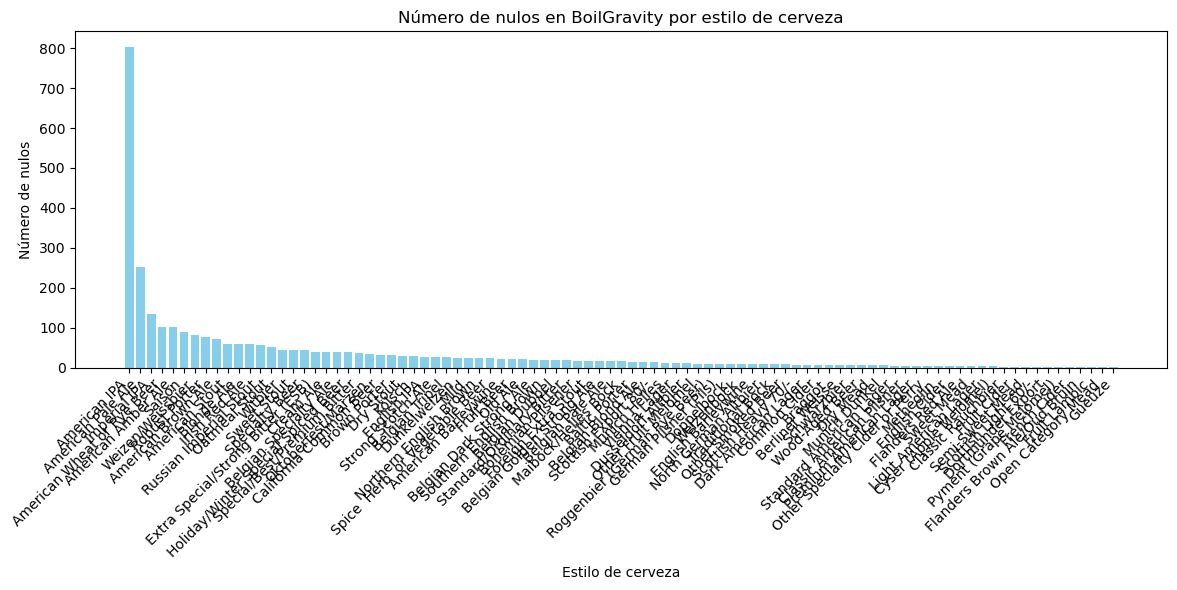

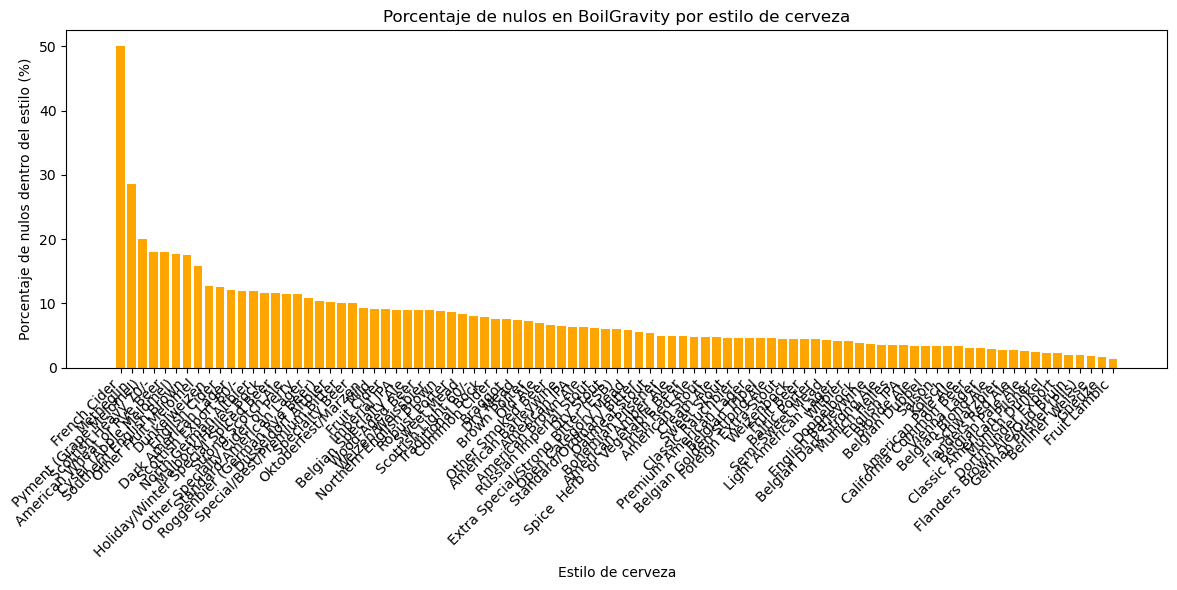

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

## df style y boilgravity

df_Style_BoilGravity = df[['Style', 'BoilGravity']].copy()

## imputacion Moda

moda_Style = df_Style_BoilGravity['Style'].mode()[0]
df_Style_BoilGravity['Style'].fillna(moda_Style, inplace=True)

print(f"Moda de Style: {moda_Style}")

## Se agrupan estilos de cervezas con valores nulos de BoilGravity

nulos_estilo = df_Style_BoilGravity.groupby('Style')['BoilGravity'].agg(Nulos=lambda x: x.isnull().sum(),Total='size').reset_index()
nulos_estilo['Porcentaje'] = (nulos_estilo['Nulos'] / nulos_estilo['Total']) * 100
nulos_estilo = nulos_estilo[nulos_estilo['Nulos'] > 0]

## absolutos, porcentuales
nulos_absolutos = nulos_estilo.sort_values(by='Nulos', ascending=False)
nulos_porcentuales = nulos_estilo.sort_values(by='Porcentaje', ascending=False)

##
print("\nNulos absolutos por estilo:")
print(nulos_absolutos[['Style','Nulos','Total']])

print("\nNulos porcentuales por estilo:")
print(nulos_porcentuales[['Style','Porcentaje','Nulos','Total']])

# Graficar
plt.figure(figsize=(12,6))
plt.bar(nulos_absolutos['Style'], nulos_absolutos['Nulos'], color='skyblue')
plt.ylabel('Número de nulos')
plt.xlabel('Estilo de cerveza')
plt.title('Número de nulos en BoilGravity por estilo de cerveza')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,6))
plt.bar(nulos_porcentuales['Style'], nulos_porcentuales['Porcentaje'], color='orange')
plt.ylabel('Porcentaje de nulos dentro del estilo (%)')
plt.xlabel('Estilo de cerveza')
plt.title('Porcentaje de nulos en BoilGravity por estilo de cerveza')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()




## Pregunta 5

1 - Codificación
2 - Estandararización
3 - Lasso 
4 - Selección de variables


1- Vamos a trabajar con el dataframe df_2 creado en la pregunta 3, este df ya se le quitaron las filas que tengan mas de 2 variables con valores nulos, posteriormente se eliminaron las variables que tengan valores sobre al promedio de valores nulos en terminos porcetuales, y al final impoutamos por la mediana y moda según tipo de variable (numerica o categorica respectivamente).


2- Se hace un script para analizar si las variables son categoricas o numericas, y tambien se busca analizar cuando subcategorias tiene cada variable.


3- Se eliminan variables categoricas que son indentificadores unicos, como: BeerID, UserID, Name y Url. Tambien se eliminan variables con alta cardinalidad, como: Style. Creando df_3. Tambien se elimina StyleID a pesar de que sea una variable numerica, ya que tambien es una variable indetificadora.


4- A las variables categoricas SugarScale y BrewMethod se le aplica codificacion One-Hot Encoder para que se pueda implementar en el modelo Lasso de manera efectiva.


5- El nuevo df será df_3_encoded, en este estan las variables SugarScale y BrewMethod  codificadas con one-hot encoder.

6- Nuestra variable objetivo es IBU y el resto se considera como predictoria. Una vez que tenemos el df limpio, imputado y codificado, se estandariza para que el modelo Lasso no interprete mas relevantes a unas variables mas que otras. 

7- Una vez tengamos estandarizado todas las variables en el df: X_scaled_df. Este df se le puede implementar el modelo Lasso de manera satisfactoria para hacer reducción de dimensionalidad y determinar cuales son las variables predictorias mas relevantes para entender el comportamiento de nuestra variable objetivo, que en este caso es IBU (y).



In [130]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LassoCV
import matplotlib.pyplot as plt

# Analizar si son categoricas o numericas, y cuantas subcategorias tienen las categoricas.

info_vars = []

for col in df_2.columns:
    if pd.api.types.is_numeric_dtype(df_2[col]):
        tipo = "Numérica"
        n_categorias = None
    else:
        tipo = "Categórica"
        n_categorias = df_2[col].nunique()
    info_vars.append([col, tipo, n_categorias])

df_info = pd.DataFrame(info_vars, columns=["Variable", "Tipo", "Subcategorías"])
print(df_info)

## Eiminación de Variables que son identificadores unicos

df_3 = df_2.drop(columns=["BeerID", "Name", "URL", "Style", "UserId;;", "StyleID"])
print("Columnas después de la limpieza:\n", df_3.columns)

# One-Hot Encoder para "SugarScale", "BrewMethod"

categoricas_onehot  = ["SugarScale", "BrewMethod"]

encoder = OneHotEncoder(sparse_output=False, drop='first')
encoded = encoder.fit_transform(df_3[categoricas_onehot])

# df variables codificadas
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(categoricas_onehot), index=df_3.index)

# Reemplazar en df_3
df_3_encoded = pd.concat([df_3.drop(columns=categoricas_onehot), encoded_df], axis=1)

print("Columnas después de One-Hot Encoding:\n", df_3_encoded.columns)
print("\nVista previa:\n", df_3_encoded.head())





       Variable        Tipo  Subcategorías
0        BeerID  Categórica        23696.0
1          Name  Categórica        20261.0
2           URL  Categórica        23696.0
3         Style  Categórica          172.0
4       StyleID    Numérica            NaN
5       Size(L)    Numérica            NaN
6            OG    Numérica            NaN
7            FG    Numérica            NaN
8           ABV    Numérica            NaN
9           IBU    Numérica            NaN
10        Color    Numérica            NaN
11     BoilSize    Numérica            NaN
12     BoilTime    Numérica            NaN
13  BoilGravity    Numérica            NaN
14   Efficiency    Numérica            NaN
15   SugarScale  Categórica            2.0
16   BrewMethod  Categórica            4.0
17    PitchRate    Numérica            NaN
18  PrimaryTemp    Numérica            NaN
19     UserId;;  Categórica         1667.0
Columnas después de la limpieza:
 Index(['Size(L)', 'OG', 'FG', 'ABV', 'IBU', 'Color', 'BoilSize'

In [128]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# Estandarizar

# Se separa variables predictorias de la variable objetivo.

y = df_3_encoded['IBU']   # variable objetivo
X = df_3_encoded.drop(columns=['IBU'])

# Se Estandariza

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Se crea df con variables estandarizadas

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)


print("Columnas estandarizadas:\n", X_scaled_df.columns.tolist())
print("\nVista previa de las variables estandarizadas:\n")
print(X_scaled_df.head())



Columnas estandarizadas:
 ['Size(L)', 'OG', 'FG', 'ABV', 'Color', 'BoilSize', 'BoilTime', 'BoilGravity', 'Efficiency', 'PitchRate', 'PrimaryTemp', 'SugarScale_Specific Gravity', 'BrewMethod_BIAB', 'BrewMethod_Partial Mash', 'BrewMethod_extract']

Vista previa de las variables estandarizadas:

     Size(L)        OG        FG       ABV     Color  BoilSize  BoilTime  \
0  -0.137570 -0.170649 -0.157604 -0.413495 -0.720857 -0.132869  0.450088   
4   0.015824 -0.168512 -0.164441  0.151860 -0.742684  0.027376  1.389871   
7  -0.142732 -0.171076 -0.155325 -0.481337 -0.627673 -0.132869  0.450088   
9  -0.142732 -0.159965 -0.148488  1.135577 -0.430393 -0.132869 -0.489695   
10 -0.120019 -0.166803 -0.155325  0.236663 -0.473207 -0.129776  1.389871   

    BoilGravity  Efficiency  PitchRate  PrimaryTemp  \
0     -0.170439    0.015836  -0.052084    -0.289261   
4     -0.164270    0.213721  -0.052084    -0.008478   
7     -0.169411    0.015836  -0.052084     0.221672   
9     -0.160158    0.015836  


Todas las variables ordenadas por importancia (coeficiente absoluto):

ABV                            17.527949
Efficiency                     -2.521085
Color                          -1.708921
PitchRate                      -1.701441
BrewMethod_extract             -0.900129
Size(L)                        -0.623511
BrewMethod_BIAB                -0.045834
BoilSize                       -0.011146
OG                             -0.000000
FG                             -0.000000
BoilTime                       -0.000000
BoilGravity                    -0.000000
PrimaryTemp                     0.000000
SugarScale_Specific Gravity     0.000000
BrewMethod_Partial Mash        -0.000000
dtype: float64


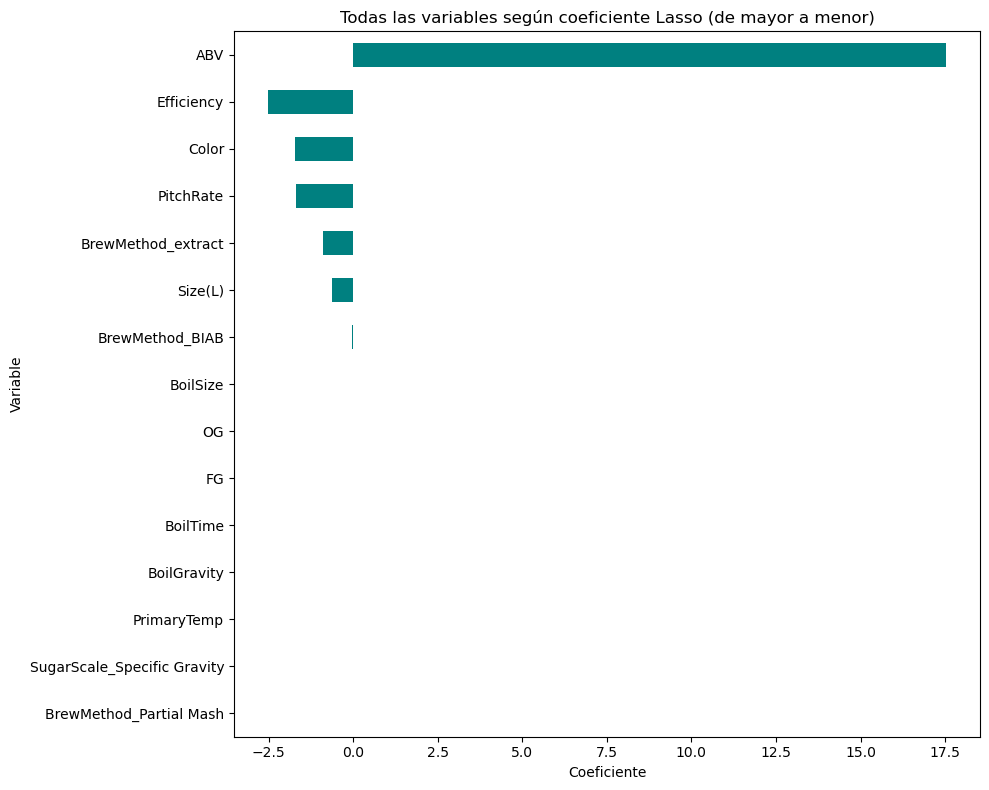


Nuevo DataFrame reducido con variables seleccionadas por Lasso:
      IBU       ABV  Efficiency     Color  PitchRate  BrewMethod_extract  \
0   17.65 -0.413495    0.015836 -0.720857  -0.052084           -0.180043   
4   17.84  0.151860    0.213721 -0.742684  -0.052084           -0.180043   
7   19.97 -0.481337    0.015836 -0.627673  -0.052084           -0.180043   
9   93.02  1.135577    0.015836 -0.430393  -0.052084           -0.180043   
10  64.26  0.236663    0.411606 -0.473207   0.605378           -0.180043   

     Size(L)  BrewMethod_BIAB  BoilSize  
0  -0.137570        -0.205149 -0.132869  
4   0.015824        -0.205149  0.027376  
7  -0.142732        -0.205149 -0.132869  
9  -0.142732        -0.205149 -0.132869  
10 -0.120019        -0.205149 -0.129776  


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
import matplotlib.pyplot as plt

# Se ajusta Lasso

lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X_scaled_df, y)

# Con lasso.alpha se encuentra alpha optimo para modelo Lasso

coeficientes = pd.Series(lasso.coef_, index=X_scaled_df.columns)

coef_ordenados = coeficientes.sort_values(key=abs, ascending=False)
print("\nTodas las variables ordenadas por importancia (coeficiente absoluto):\n")
print(coef_ordenados)

# Grafico
plt.figure(figsize=(10,8))
coef_ordenados.plot(kind='barh', color='teal')
plt.title("Todas las variables según coeficiente Lasso (de mayor a menor)")
plt.xlabel("Coeficiente")
plt.ylabel("Variable")
plt.gca().invert_yaxis()  # para que la variable más importante quede arriba
plt.tight_layout()
plt.show()


## 
variables_relevantes = coeficientes[coeficientes != 0].sort_values(key=abs, ascending=False)
df_lasso = pd.concat([y, X_scaled_df[variables_relevantes.index]], axis=1)
print("\nNuevo DataFrame reducido con variables seleccionadas por Lasso:")
print(df_lasso.head())


